In [16]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import json
from copy import deepcopy
from tqdm.notebook import tqdm
import random

In [17]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

In [18]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"device: {device}")

device: cpu


In [19]:
transform = transforms.Compose([
    transforms.ToTensor(),
])
full_train_dataset = torchvision.datasets.EMNIST(
    root='./data', split='balanced', train=True, download=True, transform=transform
)
test_dataset = torchvision.datasets.EMNIST(
    root='./data', split='balanced', train=False, download=True, transform=transform
)

100%|██████████| 562M/562M [01:12<00:00, 7.71MB/s] 


In [27]:
val_size = int(0.2 * len(full_train_dataset))
train_size = len(full_train_dataset) - val_size

In [31]:
generator = torch.Generator().manual_seed(42)
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size], generator=generator)
print(f"Train size: {len(train_dataset)}")
print(f"Val size: {val_size}")
print(f"Test size: {len(test_dataset)}")
print(f"Number of classes: {len(full_train_dataset.classes)}") 

Train size: 90240
Val size: 22560
Test size: 18800
Number of classes: 47


In [32]:
batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [33]:
images, labels = next(iter(train_loader))
print(f"Batch shape: {images.shape}")
print(f"Labels shape: {labels.shape}")
print(f"Min pixel: {images.min():.3f}, Max pixel: {images.max():.3f}")
print(f"Unique labels in batch: {torch.unique(labels)}")

Batch shape: torch.Size([128, 1, 28, 28])
Labels shape: torch.Size([128])
Min pixel: 0.000, Max pixel: 1.000
Unique labels in batch: tensor([ 0,  1,  2,  3,  5,  6,  7,  8, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19,
        20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37,
        38, 39, 40, 42, 44, 45, 46])


In [34]:
class MLP(nn.Module):
    def __init__(self, hidden_sizes=[512, 256], dropout=0.0, use_batchnorm=False):
        super().__init__()
        layers = []
        input_size = 28*28
        for i, hidden_size in enumerate(hidden_sizes):
            layers.append(nn.Linear(input_size, hidden_size))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(hidden_size))
            layers.append(nn.ReLU())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            input_size = hidden_size
        layers.append(nn.Linear(input_size, 47))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.net(x)
    
def accuracy(y_pred, y_true):
    preds = torch.argmax(y_pred, dim=1)
    return (preds == y_true).float().mean().item()

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    total_acc = 0.0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        total_acc += accuracy(outputs, labels) * images.size(0)
    avg_loss = total_loss / len(loader.dataset)
    avg_acc = total_acc / len(loader.dataset)
    return avg_loss, avg_acc

def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_acc = 0.0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)
            total_acc += accuracy(outputs, labels) * images.size(0)
    avg_loss = total_loss / len(loader.dataset)
    avg_acc = total_acc / len(loader.dataset)
    return avg_loss, avg_acc

def train_model(model, train_loader, val_loader, optimizer, criterion, device, epochs, early_stopping_patience=None):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_acc = 0.0
    best_model_state = None
    patience_counter = 0

    for epoch in range(1, epochs+1):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f"Epoch {epoch:2d} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

        if early_stopping_patience is not None:
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                best_model_state = deepcopy(model.state_dict())
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= early_stopping_patience:
                    print(f"Early stopping at epoch {epoch}")
                    break

    if early_stopping_patience is not None:
        model.load_state_dict(best_model_state)
        return history, best_val_acc
    else:
        return history, history['val_acc'][-1]

In [36]:
criterion = nn.CrossEntropyLoss()
base_epochs = 20
base_lr = 1e-3
base_hidden = [512, 256]

results = []

print("Эксперимент E1: Base MLP (no dropout, no batchnorm)")
model_e1 = MLP(hidden_sizes=base_hidden, dropout=0.0, use_batchnorm=False).to(device)
optimizer_e1 = optim.Adam(model_e1.parameters(), lr=base_lr)
history_e1, best_val_acc_e1 = train_model(model_e1, train_loader, val_loader, optimizer_e1, criterion, device, epochs=base_epochs)
results.append({
    'experiment_id': 'E1',
    'model_summary': 'hidden=[512,256], no dropout, no batchnorm',
    'optimizer': 'Adam',
    'lr': base_lr,
    'momentum': None,
    'weight_decay': 0,
    'epochs_trained': len(history_e1['train_loss']),
    'best_val_accuracy': best_val_acc_e1,
    'best_val_loss': min(history_e1['val_loss'])
})

Эксперимент E1: Base MLP (no dropout, no batchnorm)
Epoch  1 | Train Loss: 1.0843 | Train Acc: 0.6827 | Val Loss: 0.6793 | Val Acc: 0.7869
Epoch  2 | Train Loss: 0.5777 | Train Acc: 0.8109 | Val Loss: 0.5504 | Val Acc: 0.8214
Epoch  3 | Train Loss: 0.4728 | Train Acc: 0.8389 | Val Loss: 0.5077 | Val Acc: 0.8330
Epoch  4 | Train Loss: 0.4131 | Train Acc: 0.8559 | Val Loss: 0.4728 | Val Acc: 0.8424
Epoch  5 | Train Loss: 0.3691 | Train Acc: 0.8681 | Val Loss: 0.4708 | Val Acc: 0.8435
Epoch  6 | Train Loss: 0.3353 | Train Acc: 0.8769 | Val Loss: 0.4466 | Val Acc: 0.8524
Epoch  7 | Train Loss: 0.3074 | Train Acc: 0.8859 | Val Loss: 0.4626 | Val Acc: 0.8440
Epoch  8 | Train Loss: 0.2825 | Train Acc: 0.8929 | Val Loss: 0.4752 | Val Acc: 0.8418
Epoch  9 | Train Loss: 0.2592 | Train Acc: 0.9002 | Val Loss: 0.4690 | Val Acc: 0.8514
Epoch 10 | Train Loss: 0.2394 | Train Acc: 0.9059 | Val Loss: 0.4845 | Val Acc: 0.8508
Epoch 11 | Train Loss: 0.2265 | Train Acc: 0.9091 | Val Loss: 0.5108 | Val Acc

In [37]:
print("Эксперимент E2: Dropout p=0.3")
model_e2 = MLP(hidden_sizes=base_hidden, dropout=0.3, use_batchnorm=False).to(device)
optimizer_e2 = optim.Adam(model_e2.parameters(), lr=base_lr)
history_e2, best_val_acc_e2 = train_model(model_e2, train_loader, val_loader, optimizer_e2, criterion, device, epochs=base_epochs)
results.append({
    'experiment_id': 'E2',
    'model_summary': 'hidden=[512,256], dropout=0.3, no batchnorm',
    'optimizer': 'Adam',
    'lr': base_lr,
    'momentum': None,
    'weight_decay': 0,
    'epochs_trained': len(history_e2['train_loss']),
    'best_val_accuracy': best_val_acc_e2,
    'best_val_loss': min(history_e2['val_loss'])
})

Эксперимент E2: Dropout p=0.3
Epoch  1 | Train Loss: 1.2781 | Train Acc: 0.6290 | Val Loss: 0.7162 | Val Acc: 0.7777
Epoch  2 | Train Loss: 0.7430 | Train Acc: 0.7635 | Val Loss: 0.5828 | Val Acc: 0.8124
Epoch  3 | Train Loss: 0.6330 | Train Acc: 0.7917 | Val Loss: 0.5242 | Val Acc: 0.8232
Epoch  4 | Train Loss: 0.5763 | Train Acc: 0.8077 | Val Loss: 0.4935 | Val Acc: 0.8347
Epoch  5 | Train Loss: 0.5380 | Train Acc: 0.8176 | Val Loss: 0.4674 | Val Acc: 0.8431
Epoch  6 | Train Loss: 0.5115 | Train Acc: 0.8248 | Val Loss: 0.4585 | Val Acc: 0.8473
Epoch  7 | Train Loss: 0.4921 | Train Acc: 0.8294 | Val Loss: 0.4476 | Val Acc: 0.8467
Epoch  8 | Train Loss: 0.4715 | Train Acc: 0.8350 | Val Loss: 0.4425 | Val Acc: 0.8484
Epoch  9 | Train Loss: 0.4530 | Train Acc: 0.8407 | Val Loss: 0.4386 | Val Acc: 0.8526
Epoch 10 | Train Loss: 0.4438 | Train Acc: 0.8431 | Val Loss: 0.4356 | Val Acc: 0.8499
Epoch 11 | Train Loss: 0.4334 | Train Acc: 0.8460 | Val Loss: 0.4278 | Val Acc: 0.8555
Epoch 12 | Tr

In [38]:
print("Эксперимент E3: BatchNorm")
model_e3 = MLP(hidden_sizes=base_hidden, dropout=0.0, use_batchnorm=True).to(device)
optimizer_e3 = optim.Adam(model_e3.parameters(), lr=base_lr)
history_e3, best_val_acc_e3 = train_model(model_e3, train_loader, val_loader, optimizer_e3, criterion, device, epochs=base_epochs)
results.append({
    'experiment_id': 'E3',
    'model_summary': 'hidden=[512,256], no dropout, batchnorm',
    'optimizer': 'Adam',
    'lr': base_lr,
    'momentum': None,
    'weight_decay': 0,
    'epochs_trained': len(history_e3['train_loss']),
    'best_val_accuracy': best_val_acc_e3,
    'best_val_loss': min(history_e3['val_loss'])
})

best_e2_e3 = max([('E2', best_val_acc_e2), ('E3', best_val_acc_e3)], key=lambda x: x[1])
print(f"Лучший из E2/E3: {best_e2_e3[0]} с accuracy {best_e2_e3[1]:.4f}")


Эксперимент E3: BatchNorm
Epoch  1 | Train Loss: 0.8509 | Train Acc: 0.7514 | Val Loss: 0.5624 | Val Acc: 0.8162
Epoch  2 | Train Loss: 0.4891 | Train Acc: 0.8348 | Val Loss: 0.4822 | Val Acc: 0.8378
Epoch  3 | Train Loss: 0.4104 | Train Acc: 0.8558 | Val Loss: 0.4636 | Val Acc: 0.8412
Epoch  4 | Train Loss: 0.3646 | Train Acc: 0.8685 | Val Loss: 0.4534 | Val Acc: 0.8457
Epoch  5 | Train Loss: 0.3281 | Train Acc: 0.8786 | Val Loss: 0.4595 | Val Acc: 0.8433
Epoch  6 | Train Loss: 0.2992 | Train Acc: 0.8881 | Val Loss: 0.4407 | Val Acc: 0.8526
Epoch  7 | Train Loss: 0.2738 | Train Acc: 0.8943 | Val Loss: 0.4466 | Val Acc: 0.8515
Epoch  8 | Train Loss: 0.2545 | Train Acc: 0.9013 | Val Loss: 0.4621 | Val Acc: 0.8522
Epoch  9 | Train Loss: 0.2357 | Train Acc: 0.9070 | Val Loss: 0.4598 | Val Acc: 0.8515
Epoch 10 | Train Loss: 0.2209 | Train Acc: 0.9114 | Val Loss: 0.4757 | Val Acc: 0.8498
Epoch 11 | Train Loss: 0.2076 | Train Acc: 0.9167 | Val Loss: 0.4880 | Val Acc: 0.8490
Epoch 12 | Train 

In [39]:
print(f"Эксперимент E4: EarlyStopping на основе {best_e2_e3[0]}")
if best_e2_e3[0] == 'E2':
    model_e4 = MLP(hidden_sizes=base_hidden, dropout=0.3, use_batchnorm=False).to(device)
    model_summary_e4 = 'hidden=[512,256], dropout=0.3, no batchnorm'
else:
    model_e4 = MLP(hidden_sizes=base_hidden, dropout=0.0, use_batchnorm=True).to(device)
    model_summary_e4 = 'hidden=[512,256], no dropout, batchnorm'

optimizer_e4 = optim.Adam(model_e4.parameters(), lr=base_lr)
history_e4, best_val_acc_e4 = train_model(model_e4, train_loader, val_loader, optimizer_e4, criterion, device, epochs=base_epochs, early_stopping_patience=5)
results.append({
    'experiment_id': 'E4',
    'model_summary': model_summary_e4,
    'optimizer': 'Adam',
    'lr': base_lr,
    'momentum': None,
    'weight_decay': 0,
    'epochs_trained': len(history_e4['train_loss']),
    'best_val_accuracy': best_val_acc_e4,
    'best_val_loss': min(history_e4['val_loss'])
})

Эксперимент E4: EarlyStopping на основе E2
Epoch  1 | Train Loss: 1.2842 | Train Acc: 0.6264 | Val Loss: 0.7090 | Val Acc: 0.7810
Epoch  2 | Train Loss: 0.7414 | Train Acc: 0.7626 | Val Loss: 0.5685 | Val Acc: 0.8143
Epoch  3 | Train Loss: 0.6316 | Train Acc: 0.7930 | Val Loss: 0.5320 | Val Acc: 0.8218
Epoch  4 | Train Loss: 0.5747 | Train Acc: 0.8078 | Val Loss: 0.4916 | Val Acc: 0.8343
Epoch  5 | Train Loss: 0.5384 | Train Acc: 0.8184 | Val Loss: 0.4781 | Val Acc: 0.8383
Epoch  6 | Train Loss: 0.5083 | Train Acc: 0.8254 | Val Loss: 0.4510 | Val Acc: 0.8454
Epoch  7 | Train Loss: 0.4844 | Train Acc: 0.8316 | Val Loss: 0.4533 | Val Acc: 0.8445
Epoch  8 | Train Loss: 0.4663 | Train Acc: 0.8361 | Val Loss: 0.4429 | Val Acc: 0.8488
Epoch  9 | Train Loss: 0.4529 | Train Acc: 0.8399 | Val Loss: 0.4335 | Val Acc: 0.8543
Epoch 10 | Train Loss: 0.4410 | Train Acc: 0.8438 | Val Loss: 0.4285 | Val Acc: 0.8543
Epoch 11 | Train Loss: 0.4318 | Train Acc: 0.8463 | Val Loss: 0.4254 | Val Acc: 0.8543


In [40]:
best_model = model_e4
best_history = history_e4

o_epochs_small = 8
o_epochs_medium = 10

print("Эксперимент O1: Adam, lr=1e-1")
model_o1 = MLP(hidden_sizes=base_hidden, 
               dropout=(0.3 if best_e2_e3[0]=='E2' else 0.0), 
               use_batchnorm=(best_e2_e3[0]=='E3')).to(device)
optimizer_o1 = optim.Adam(model_o1.parameters(), lr=1e-1)
history_o1, _ = train_model(model_o1, train_loader, val_loader, optimizer_o1, criterion, device, epochs=o_epochs_small)
results.append({
    'experiment_id': 'O1',
    'model_summary': model_summary_e4,
    'optimizer': 'Adam',
    'lr': 1e-1,
    'momentum': None,
    'weight_decay': 0,
    'epochs_trained': len(history_o1['train_loss']),
    'best_val_accuracy': max(history_o1['val_acc']),
    'best_val_loss': min(history_o1['val_loss'])
})


Эксперимент O1: Adam, lr=1e-1
Epoch  1 | Train Loss: 4.9672 | Train Acc: 0.0208 | Val Loss: 3.8650 | Val Acc: 0.0211
Epoch  2 | Train Loss: 3.8658 | Train Acc: 0.0210 | Val Loss: 3.8636 | Val Acc: 0.0203
Epoch  3 | Train Loss: 3.8643 | Train Acc: 0.0208 | Val Loss: 3.8645 | Val Acc: 0.0213
Epoch  4 | Train Loss: 3.8647 | Train Acc: 0.0221 | Val Loss: 3.8688 | Val Acc: 0.0203
Epoch  5 | Train Loss: 3.8647 | Train Acc: 0.0212 | Val Loss: 3.8673 | Val Acc: 0.0219
Epoch  6 | Train Loss: 3.8651 | Train Acc: 0.0204 | Val Loss: 3.8668 | Val Acc: 0.0204
Epoch  7 | Train Loss: 3.8651 | Train Acc: 0.0211 | Val Loss: 3.8649 | Val Acc: 0.0215
Epoch  8 | Train Loss: 3.8645 | Train Acc: 0.0208 | Val Loss: 3.8612 | Val Acc: 0.0215


In [41]:
print("Эксперимент O2: Adam, lr=1e-5")
model_o2 = MLP(hidden_sizes=base_hidden, 
               dropout=(0.3 if best_e2_e3[0]=='E2' else 0.0), 
               use_batchnorm=(best_e2_e3[0]=='E3')).to(device)
optimizer_o2 = optim.Adam(model_o2.parameters(), lr=1e-5)
history_o2, _ = train_model(model_o2, train_loader, val_loader, optimizer_o2, criterion, device, epochs=o_epochs_small)
results.append({
    'experiment_id': 'O2',
    'model_summary': model_summary_e4,
    'optimizer': 'Adam',
    'lr': 1e-5,
    'momentum': None,
    'weight_decay': 0,
    'epochs_trained': len(history_o2['train_loss']),
    'best_val_accuracy': max(history_o2['val_acc']),
    'best_val_loss': min(history_o2['val_loss'])
})



Эксперимент O2: Adam, lr=1e-5
Epoch  1 | Train Loss: 3.7677 | Train Acc: 0.0978 | Val Loss: 3.6067 | Val Acc: 0.2723
Epoch  2 | Train Loss: 3.3472 | Train Acc: 0.2481 | Val Loss: 2.9863 | Val Acc: 0.4153
Epoch  3 | Train Loss: 2.7881 | Train Acc: 0.3356 | Val Loss: 2.4399 | Val Acc: 0.4887
Epoch  4 | Train Loss: 2.3980 | Train Acc: 0.3858 | Val Loss: 2.0981 | Val Acc: 0.5221
Epoch  5 | Train Loss: 2.1611 | Train Acc: 0.4263 | Val Loss: 1.8867 | Val Acc: 0.5514
Epoch  6 | Train Loss: 1.9995 | Train Acc: 0.4578 | Val Loss: 1.7470 | Val Acc: 0.5685
Epoch  7 | Train Loss: 1.8908 | Train Acc: 0.4807 | Val Loss: 1.6480 | Val Acc: 0.5837
Epoch  8 | Train Loss: 1.8033 | Train Acc: 0.5000 | Val Loss: 1.5744 | Val Acc: 0.5958


In [42]:
print("Эксперимент O3: SGD, lr=1e-2, momentum=0.9, weight_decay=1e-4")
model_o3 = MLP(hidden_sizes=base_hidden, 
               dropout=(0.3 if best_e2_e3[0]=='E2' else 0.0), 
               use_batchnorm=(best_e2_e3[0]=='E3')).to(device)
optimizer_o3 = optim.SGD(model_o3.parameters(), lr=1e-2, momentum=0.9, weight_decay=1e-4)
history_o3, _ = train_model(model_o3, train_loader, val_loader, optimizer_o3, criterion, device, epochs=o_epochs_medium)
results.append({
    'experiment_id': 'O3',
    'model_summary': model_summary_e4,
    'optimizer': 'SGD',
    'lr': 1e-2,
    'momentum': 0.9,
    'weight_decay': 1e-4,
    'epochs_trained': len(history_o3['train_loss']),
    'best_val_accuracy': max(history_o3['val_acc']),
    'best_val_loss': min(history_o3['val_loss'])
})

Эксперимент O3: SGD, lr=1e-2, momentum=0.9, weight_decay=1e-4
Epoch  1 | Train Loss: 2.2912 | Train Acc: 0.3912 | Val Loss: 1.2523 | Val Acc: 0.6410
Epoch  2 | Train Loss: 1.1976 | Train Acc: 0.6464 | Val Loss: 0.9128 | Val Acc: 0.7314
Epoch  3 | Train Loss: 0.9524 | Train Acc: 0.7120 | Val Loss: 0.7576 | Val Acc: 0.7676
Epoch  4 | Train Loss: 0.8276 | Train Acc: 0.7440 | Val Loss: 0.6700 | Val Acc: 0.7937
Epoch  5 | Train Loss: 0.7491 | Train Acc: 0.7657 | Val Loss: 0.6236 | Val Acc: 0.8032
Epoch  6 | Train Loss: 0.6955 | Train Acc: 0.7787 | Val Loss: 0.5798 | Val Acc: 0.8163
Epoch  7 | Train Loss: 0.6565 | Train Acc: 0.7899 | Val Loss: 0.5558 | Val Acc: 0.8180
Epoch  8 | Train Loss: 0.6269 | Train Acc: 0.7960 | Val Loss: 0.5319 | Val Acc: 0.8291
Epoch  9 | Train Loss: 0.5986 | Train Acc: 0.8059 | Val Loss: 0.5209 | Val Acc: 0.8280
Epoch 10 | Train Loss: 0.5748 | Train Acc: 0.8124 | Val Loss: 0.5037 | Val Acc: 0.8347


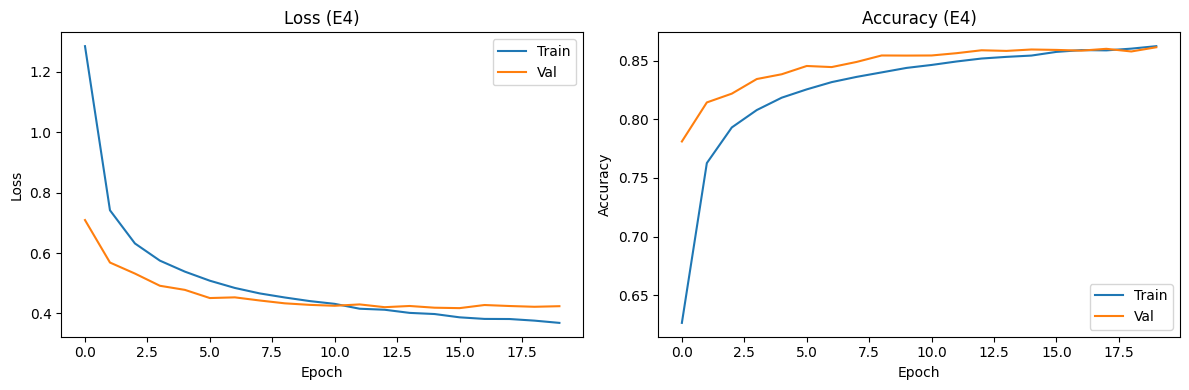

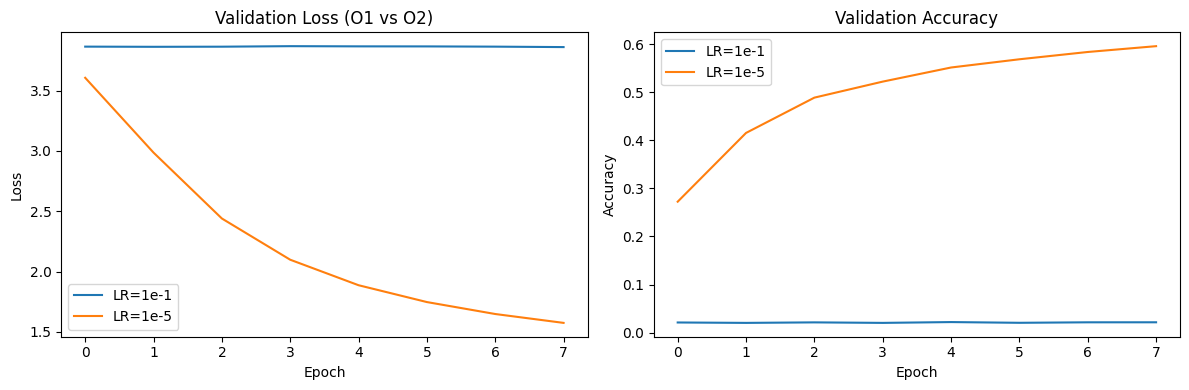

Test accuracy of best model (E4): 0.8543
Test loss: 0.4450


In [44]:
df_results = pd.DataFrame(results)

df_results.insert(0, 'dataset', 'EMNIST')
df_results.insert(1, 'seed', 42)
df_results.to_csv('artifacts/runs.csv', index=False)

torch.save(best_model.state_dict(), 'artifacts/best_model.pt')

config = {
    'experiment_id': 'E4',
    'dataset': 'EMNIST',
    'seed': 42,
    'model_summary': model_summary_e4,
    'optimizer': 'Adam',
    'lr': base_lr,
    'momentum': None,
    'weight_decay': 0,
    'epochs_trained': len(best_history['train_loss']),
    'best_val_accuracy': best_val_acc_e4,
    'best_val_loss': min(best_history['val_loss']),
    'early_stopping_patience': 5
}
with open('artifacts/best_config.json', 'w') as f:
    json.dump(config, f, indent=4)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(best_history['train_loss'], label='Train')
plt.plot(best_history['val_loss'], label='Val')
plt.title('Loss (E4)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(best_history['train_acc'], label='Train')
plt.plot(best_history['val_acc'], label='Val')
plt.title('Accuracy (E4)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.savefig('artifacts/figures/curves_best.png', dpi=150)
plt.show()

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history_o1['val_loss'], label='LR=1e-1')
plt.plot(history_o2['val_loss'], label='LR=1e-5')
plt.title('Validation Loss (O1 vs O2)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_o1['val_acc'], label='LR=1e-1')
plt.plot(history_o2['val_acc'], label='LR=1e-5')
plt.title('Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.savefig('artifacts/figures/curves_lr_extremes.png', dpi=150)
plt.show()


test_loss, test_acc = evaluate(best_model, test_loader, criterion, device)
print(f"Test accuracy of best model (E4): {test_acc:.4f}")
print(f"Test loss: {test_loss:.4f}")